In [1]:
import pandas as pd
import numpy as np
import pint
ureg = pint.get_application_registry()
import plotly.graph_objects as go

In [2]:
from aircraftdetective.processing.usdot import process_data_usdot_t2
from aircraftdetective.processing.acftdb import _read_engine_database
from aircraftdetective.processing.literature import process_data_weinold_database

from aircraftdetective.calculations.weight import calculate_weight_metrics

from aircraftdetective.calculations.engines import (
    determine_takeoff_to_cruise_tsfc_ratio,
    scale_engine_data_from_icao_emissions_database
)
from aircraftdetective.calculations.aerodynamics import compute_lift_to_drag_ratio
from aircraftdetective.processing.a4a import process_a4a_traffic_data
from aircraftdetective.utility.tabular import (
    left_merge_wildcard,
    export_typed_dataframe_to_excel
)
from aircraftdetective.utility.statistics import _compute_polynomials_from_dataframe
from aircraftdetective.utility.tabular import update_column_data
from aircraftdetective.calculations.decomposition import compute_efficiency_improvement_metrics

In [3]:
df_acft = process_data_weinold_database()
df_engines_acftdb = _read_engine_database()
df_literature = process_data_weinold_database(sheet_name='Literature Data')
df_operations = process_a4a_traffic_data()

In [4]:
dict_tsfc_scaling = determine_takeoff_to_cruise_tsfc_ratio(degree=1, plot=True)
df_engines_icao_scaled = scale_engine_data_from_icao_emissions_database(
    scaling_polynomial=dict_tsfc_scaling['polynomial'],
)
df_engines_icao_scaled.drop(columns=['Final Test Date'], inplace=True)

In [5]:
df_merged = left_merge_wildcard(
    df_left=df_acft,
    df_right=df_engines_icao_scaled,
    left_on='Engine Designation (ICAO)',
    right_on='Engine Identification',
)
df_merged = left_merge_wildcard(
    df_left=df_merged,
    df_right=df_engines_acftdb,
    left_on='Engine Designation (aircraft-database.com)',
    right_on='Engine Designation',
)
df_merged = update_column_data(
    df_main=df_merged,
    df_other=df_literature,
    merge_column='Aircraft Designation (Literature)',
    list_columns=['TSFC (cruise)'],
)
df_merged = compute_lift_to_drag_ratio(
    df_merged,
    beta = {
        'Wide': 0.04,
        'Narrow': 0.06,
        'Regional': 0.09
    }
)
df_merged = calculate_weight_metrics(df_merged)

In [6]:
df_t2 = process_data_usdot_t2()
df_t2 = df_t2.groupby('Aircraft Designation (US DOT Schedule T2)').mean()
df_t2.drop(columns=['Year'], inplace=True)
df_merged = pd.merge(
    how='left',
    left=df_merged,
    right=df_t2,
    left_on='Aircraft Designation (US DOT Schedule T2)',
    right_on='Aircraft Designation (US DOT Schedule T2)'
)

In [7]:
df_merged = update_column_data(
    df_main=df_merged,
    df_other=df_literature,
    merge_column='Aircraft Designation (Literature)',
    list_columns=['L/D', 'TSFC (cruise)', 'Energy Use (per ASK)'],
)

In [8]:
df_merged.head(4)

,Manufacturer,Aircraft Designation,Aircraft Designation (Literature),Aircraft Designation (aircraft-database.com),Aircraft Designation (US DOT Schedule T2),Type,YOI,Engine Designation (ICAO),Engine Designation (aircraft-database.com),Design Range,...,OEW/MTOW,OEW/Exit Limit,Fuel/Available Seat Distance,Fuel/Revenue Seat Distance,Fuel Flow,Energy Use (per ASK),Updated?(Energy Use (per ASK)),Energy Intensity (per RPK),Airborne Efficiency,Revenue Passenger Distance
0,Airbus,A220-100,NaN,A220-100,A200-100 BD-500-1A10,Narrow,2016,PW1519G,PW1519G,6700.0,...,0.558161648177496,293.5,0.014342237147026128,0.019219012506973217,672.7058856593372,1.1706056571081447,False,1.5686454305603215,0.8278189758393693,716976819.0
1,Airbus,A220-300,NaN,A220-300,A220-300 BD-500-1A11,Narrow,2016,PW1521G,PW1521G,6300.0,...,0.5229901269393512,264.85714285714283,0.013380505469806998,0.016912406439006062,840.4810493380713,1.0921096365479037,False,1.380381487899033,0.8150626646059727,483745589.4680851
2,Airbus,A300-600,A300-600,A300 B4-600,Airbus Industrie A300-600/R/CF/RCF,Wide,1984,CF6-80C2A5,CF6-80C2A5,6852.0,...,0.4800606060606061,219.41828254847644,0.0167187036552123,0.02339057742031206,1967.2451931194253,1.3176,True,1.9091263078801362,0.8592071245393107,820130276.8352941
3,Airbus,A300-600,A300-600,A300 B4-601,Airbus Industrie A300-600/R/CF/RCF,Wide,1986,PW4158,PW4158,6852.0,...,0.4797030303030303,219.25484764542935,0.0167187036552123,0.02339057742031206,1967.2451931194253,1.3176,True,1.9091263078801362,0.8592071245393107,820130276.8352941


In [9]:
poly_engines = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='TSFC (cruise)',
    degree=3,
    plot=True
)

In [10]:
poly_aero = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='L/D',
    degree=3,
    plot=True
)

In [12]:
poly_weight = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='OEW/Exit Limit',
    degree=1,
    plot=True
)

In [13]:
poly_eu = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='Energy Use (per ASK)',
    degree=5,
    plot=True
)

In [17]:
poly_ei = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='Energy Intensity (per RPK)',
    degree=4,
    plot=True
)

In [15]:
poly_weight = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='OEW/Exit Limit',
    degree=1,
    plot=True
)

In [18]:
years = np.arange(1950, 2025)
df = pd.DataFrame({
    'Year': years,
    'TSFC (cruise)': poly_engines['polynomial'](years),
    'L/D': poly_aero['polynomial'](years),
    'OEW/Exit Limit': poly_weight['polynomial'](years),
    'Energy Use (per ASK)': poly_eu['polynomial'](years),
    'Energy Intensity (per RPK)': poly_ei['polynomial'](years)
})
df = pd.merge(
    left=df,
    right=df_operations,
    left_on='Year',
    right_on='Year'
)
df

,Year,TSFC (cruise),L/D,OEW/Exit Limit,Energy Use (per ASK),Energy Intensity (per RPK),SLF
0,1950,31.639284,12.479918,302.595709,10.223200,9.941771,0.608696
1,1951,30.731612,12.553415,301.816379,9.100829,9.215123,0.636364
2,1952,29.863881,12.629113,301.037049,8.096041,8.539365,0.625000
3,1953,29.035172,12.706931,300.257719,7.199568,7.912159,0.626667
4,1954,28.244566,12.786785,299.478389,6.402630,7.331221,0.604651
...,...,...,...,...,...,...,...
69,2019,14.568055,18.392310,248.821937,0.501479,1.830026,0.823833
70,2020,14.260641,18.424103,248.042607,0.243830,1.864990,0.652049
71,2021,13.929766,18.452401,247.263277,-0.059952,1.911975,0.676303
72,2022,13.574511,18.477125,246.483947,-0.415330,1.972245,0.786065


In [19]:
df_index = compute_efficiency_improvement_metrics(df)

In [27]:
df_index.columns

Index(['Year', 'TSFC (cruise)', 'L/D', 'OEW/Exit Limit',
       'Energy Use (per ASK)', 'Energy Intensity (per RPK)', 'SLF',
       'Index(EU)', 'Percent(EU)', 'Index(EI)', 'Percent(EI)',
       'Index(Engines)', 'Percent(Engines)', 'Index(Weight)',
       'Percent(Weight)', 'Index(Aerodynamics)', 'Percent(Aerodynamics)',
       'Index(Operations)', 'Percent(Operations)'],
      dtype='object')

<Axes: xlabel='Year'>

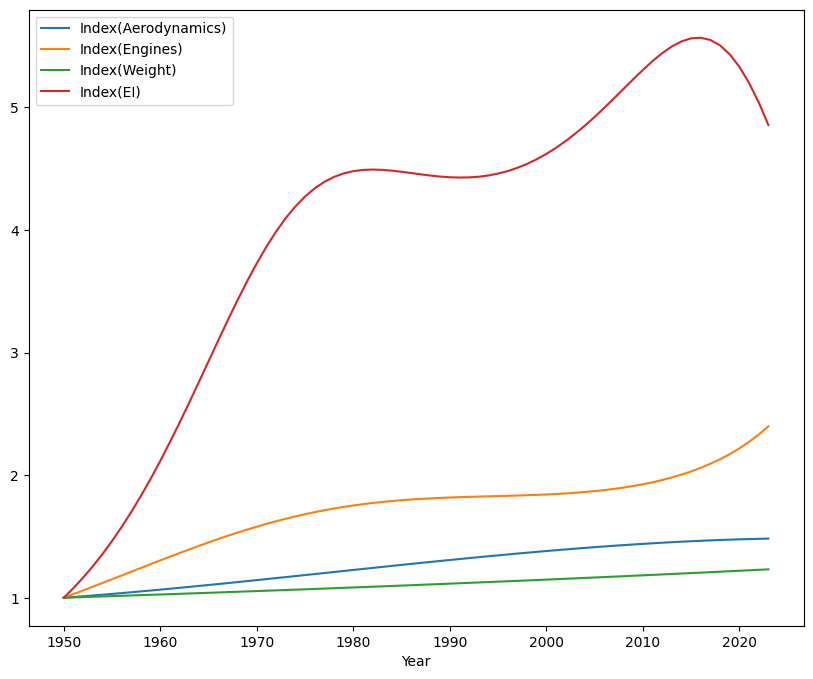

In [20]:
df_index.plot(
    x='Year',
    y=[
        'Index(Aerodynamics)',
        'Index(Engines)',
        'Index(Weight)',
        'Index(EI)',
    ],
    subplots=False,
    layout=(3,2),
    figsize=(10,8),
)

In [32]:
import pandas as pd
import numpy as np
import math
from typing import List

def _compute_lmdi_factor_contributions_vectorized(
    df: pd.DataFrame,
    aggregate_col: str,
    factor_cols: List[str]
) -> pd.DataFrame:
    r"""
    Vectorized computation of LMDI-I contributions, comparing every
    row to the first row (t_1).

    This function calculates the contribution of one or more factors
    to the change in an aggregate, relative to the data in the
    first row (`.iloc[0]`).

    **The new contribution columns are added directly to the
    input DataFrame.**

    Parameters
    ----------
    df : pd.DataFrame
        The input DataFrame. The first row is treated as $t_1$.
        This DataFrame will be modified in-place by adding new
        columns.
    aggregate_col : str
        The name of the column containing the aggregate values ($C$).
    factor_cols : List[str]
        A list of column names containing the factor values ($C_i$).

    Returns
    -------
    pd.DataFrame
        The original DataFrame, now modified to include new columns
        named `contribution_{factor_col}`.
    """
    if df.empty:
        return df  # Return the empty DataFrame

    if not isinstance(factor_cols, list):
        raise TypeError("factor_cols must be a list of column names.")

    # --- Set t1 (first row) and t2 (all rows) for Aggregate ---
    
    # t1 value is a scalar from the first row
    aggregate_t1 = df[aggregate_col].iloc[0]
    # t2 values are the full Series
    aggregate_t2 = df[aggregate_col]

    # --- Calculate the Common Log-Mean Aggregate Term ---
    # This term $L(C(t_2), C(t_1))$ is the same for all factor calcs.
    
    delta_aggregate = aggregate_t2 - aggregate_t1
    log_diff_aggregate = np.log(aggregate_t2) - np.log(aggregate_t1)
    
    # Use np.where to handle the first row (t1 vs t1)
    # where delta_aggregate == 0, avoiding 0/0 = NaN
    log_mean_aggregate = np.where(
        delta_aggregate == 0,
        aggregate_t1,  # If no change, log mean is the value itself
        delta_aggregate / log_diff_aggregate
    )
    
    # Convert to Series to ensure index is preserved
    log_mean_aggregate = pd.Series(log_mean_aggregate, index=df.index)

    # --- Calculate and Add Contribution for Each Factor ---
    
    for col in factor_cols:
        # Get t1 (scalar) and t2 (Series) for this factor
        factor_t1 = df[col].iloc[0]
        factor_t2 = df[col]

        # Calculate the log-ratio for this factor
        log_ratio_factor = np.log(factor_t2 / factor_t1)
        
        # $\Delta C_i = L(C(t_2), C(t_1)) \times \ln(C_i(t_2) / C_i(t_1))$
        delta_contribution = log_mean_aggregate * log_ratio_factor
        
        # Add the result as a new column to the *original* DataFrame
        # .fillna(0.0) handles the first row (log(1)=0)
        df[f"contribution_{col}"] = delta_contribution.fillna(0.0)
        
    return df

In [30]:
df_index.columns

Index(['Year', 'TSFC (cruise)', 'L/D', 'OEW/Exit Limit',
       'Energy Use (per ASK)', 'Energy Intensity (per RPK)', 'SLF',
       'Index(EU)', 'Percent(EU)', 'Index(EI)', 'Percent(EI)',
       'Index(Engines)', 'Percent(Engines)', 'Index(Weight)',
       'Percent(Weight)', 'Index(Aerodynamics)', 'Percent(Aerodynamics)',
       'Index(Operations)', 'Percent(Operations)'],
      dtype='object')

In [34]:
df_index = _compute_lmdi_factor_contributions_vectorized(
    df=df_index,
    aggregate_col='Index(EU)',
    factor_cols=[
        'Index(Engines)',
        'Index(Aerodynamics)',
        'Index(Weight)'
    ]
)

/Users/michaelweinold/github/aircraftdetective/.venvacftdet/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



In [39]:
df_index

,Year,TSFC (cruise),L/D,OEW/Exit Limit,Energy Use (per ASK),Energy Intensity (per RPK),SLF,Index(EU),Percent(EU),Index(EI),...,Percent(Engines),Index(Weight),Percent(Weight),Index(Aerodynamics),Percent(Aerodynamics),Index(Operations),Percent(Operations),contribution_Index(Engines),contribution_Index(Aerodynamics),contribution_Index(Weight)
0,1950,31.639284,12.479918,302.595709,10.223200,9.941771,0.608696,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
1,1951,30.731612,12.553415,301.816379,9.100829,9.215123,0.636364,1.123326,12.332622,1.078854,...,2.953545,1.002582,0.258213,1.005889,0.588917,1.045455,4.545455,0.030868,0.006227,0.002735
2,1952,29.863881,12.629113,301.037049,8.096041,8.539365,0.625000,1.262741,26.274068,1.164228,...,5.944985,1.005178,0.517764,1.011955,1.195478,1.026786,2.678571,0.065042,0.013384,0.005816
3,1953,29.035172,12.706931,300.257719,7.199568,7.912159,0.626667,1.419974,41.997408,1.256518,...,8.968820,1.007787,0.778661,1.018190,1.819022,1.029524,2.952381,0.102876,0.021591,0.009290
4,1954,28.244566,12.786785,299.478389,6.402630,7.331221,0.604651,1.596719,59.671896,1.356087,...,12.019014,1.010409,1.040917,1.024589,2.458886,0.993355,-0.664452,0.144730,0.030976,0.013205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,2019,14.568055,18.392310,248.821937,0.501479,1.830026,0.823833,20.386107,1938.610663,5.432586,...,117.182626,1.216113,21.611347,1.473752,47.375245,1.353439,35.343946,4.987059,2.493707,1.258133
70,2020,14.260641,18.424103,248.042607,0.243830,1.864990,0.652049,41.927651,4092.765053,5.330738,...,121.864392,1.219934,21.993440,1.476300,47.629992,1.071224,7.122393,8.730076,4.267437,2.177842
71,2021,13.929766,18.452401,247.263277,-0.059952,1.911975,0.676303,-170.521928,-17152.192806,5.199739,...,127.134357,1.223779,22.377942,1.478567,47.856748,1.111068,11.106848,0.000000,0.000000,0.000000
72,2022,13.574511,18.477125,246.483947,-0.415330,1.972245,0.786065,-24.614659,-2561.465892,5.040840,...,133.078628,1.227649,22.764875,1.480549,48.054852,1.291393,29.139309,0.000000,0.000000,0.000000


In [43]:
# Stacked bars for contributions and line for Index(EU)
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_index['Year'],
    y=df_index['contribution_Index(Engines)'],
    name='Contribution: Engines',
    marker_color='rgba(55,83,109,0.8)',
))
fig.add_trace(go.Bar(
    x=df_index['Year'],
    y=df_index['contribution_Index(Aerodynamics)'],
    name='Contribution: Aerodynamics',
    marker_color='rgba(26,118,255,0.8)',
))
fig.add_trace(go.Bar(
    x=df_index['Year'],
    y=df_index['contribution_Index(Weight)'],
    name='Contribution: Weight',
    marker_color='rgba(50,205,50,0.8)',
))

fig.add_trace(go.Scatter(
    x=df_index['Year'],
    y=df_index['Index(EU)']-1,
    name='Index(EU)',
    mode='lines+markers',
    line=dict(color='orange', width=3),
    marker=dict(size=6),
))

fig.update_layout(
    bargap=0.2,
    barmode='stack',
)
fig.update_xaxes(range=[1950, 2025])
fig.update_yaxes(range=[0, 50])

fig.show()